# NSE Stock Analysis

This notebook loads the processed stock data with technical metrics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('nse_stock_data_with_metrics.csv')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Display the first few rows
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,RSI_14,3DMA,3EMA,...,200DMA_LINE_ANGLE,3EMA_LINE_ANGLE,20EMA_LINE_ANGLE,100EMA_LINE_ANGLE,200EMA_LINE_ANGLE,3VWMA_LINE_ANGLE,20VWMA_LINE_ANGLE,100VWMA_LINE_ANGLE,200VWMA_LINE_ANGLE,RSI_14_angle
0,2025-12-23,ABB,5185.0,5215.0,5151.0,5203.5,60934.0,56.858564,5187.166667,5188.390084,...,2.479083,33.619675,6.055593,-4.358601,-9.453846,45.094009,29.938545,-13.072997,10.288170,87.954656
1,2025-12-22,ABB,5180.5,5233.0,5170.0,5181.0,67499.0,49.867900,5151.833333,5173.280167,...,2.163004,-35.713194,-5.628711,-6.753957,-10.615866,-64.003655,17.782945,-15.247972,9.211211,84.791548
2,2025-12-19,ABB,5106.0,5191.5,5100.0,5177.0,351488.0,49.177090,5148.500000,5165.560335,...,0.987110,-58.272796,-7.365576,-7.103533,-10.814754,-68.659267,6.907292,-14.219185,6.719037,-82.760034
3,2025-12-18,ABB,5185.0,5185.0,5075.5,5097.5,362593.0,44.420446,5170.166667,5154.120670,...,-1.059928,-63.361850,-0.610897,-5.833674,-10.259017,-69.229773,6.474874,-14.266426,1.424306,-88.156652
4,2025-12-17,ABB,5238.0,5262.5,5152.0,5171.0,85858.0,44.938092,5232.666667,5210.741340,...,-0.837397,-22.978571,20.357213,-1.846852,-8.448473,13.457534,26.646427,-13.912909,1.595932,-88.128302


In [2]:
# Check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106182 entries, 0 to 106181
Data columns (total 33 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                106182 non-null  datetime64[ns]
 1   Ticker              106182 non-null  object        
 2   Open                106182 non-null  float64       
 3   High                106182 non-null  float64       
 4   Low                 106182 non-null  float64       
 5   Close               106182 non-null  float64       
 6   Volume              106182 non-null  float64       
 7   RSI_14              105964 non-null  float64       
 8   3DMA                106182 non-null  float64       
 9   3EMA                106182 non-null  float64       
 10  20DMA               106182 non-null  float64       
 11  20EMA               106182 non-null  float64       
 12  100DMA              106182 non-null  float64       
 13  100EMA              106182 no

In [3]:
last_3_dates = sorted(df['Date'].unique())[-3:]
recent_df=df[df['Date'].isin(last_3_dates)]
filtered_stocks = recent_df[
    ((recent_df['20VWMA'] - recent_df['20DMA']) / recent_df['20DMA'] > 0.02) & 
    (recent_df['200DMA_LINE_ANGLE'] > 10)
]['Ticker'].unique()
recent_df.describe()


,Date,Open,High,Low,Close,Volume,RSI_14,3DMA,3EMA,20DMA,...,200DMA_LINE_ANGLE,3EMA_LINE_ANGLE,20EMA_LINE_ANGLE,100EMA_LINE_ANGLE,200EMA_LINE_ANGLE,3VWMA_LINE_ANGLE,20VWMA_LINE_ANGLE,100VWMA_LINE_ANGLE,200VWMA_LINE_ANGLE,RSI_14_angle
count,491,491.000000,491.000000,491.000000,491.000000,4.910000e+02,491.000000,491.000000,491.000000,491.000000,...,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000
mean,2025-12-20 18:57:55.356415488,3405.283483,3442.670326,3379.925663,3417.723301,6.614418e+06,47.488200,3398.046158,3405.150048,3429.121225,...,11.668398,11.607022,-7.356379,-1.403005,1.157772,1.006150,-8.035788,1.012852,14.683690,43.408408
min,2025-12-19 00:00:00,2.810000,2.920000,2.750000,2.800000,1.100000e+03,6.426094,2.800000,2.814774,2.958000,...,-59.779022,-83.081057,-70.438956,-60.820514,-54.291689,-83.833975,-82.670845,-73.167034,-66.893838,-88.940562
25%,2025-12-19 00:00:00,332.849991,336.750000,331.175003,334.750000,3.881780e+05,38.136424,332.316671,332.853703,336.191251,...,1.149896,-34.161901,-33.458704,-18.399056,-12.143233,-49.918971,-35.506624,-12.981395,5.152431,-18.807676
50%,2025-12-22 00:00:00,871.000000,913.500000,867.000000,901.700012,1.059210e+06,46.834522,878.450012,882.423698,869.192502,...,10.477305,19.427503,-14.198383,-3.512591,-0.337978,4.614676,-10.785984,0.481858,13.525305,85.855857
75%,2025-12-22 00:00:00,2261.849976,2279.400024,2254.799927,2271.750000,4.291426e+06,55.946305,2258.816691,2263.732635,2304.989996,...,22.795765,53.727789,18.326477,15.235923,13.203371,47.996680,17.225923,13.717742,24.152950,88.295539
max,2025-12-23 00:00:00,154880.000000,155385.000000,153400.000000,153900.000000,1.042676e+09,87.210480,153578.333333,153412.126755,153186.500000,...,49.514865,83.874118,75.819746,58.330991,45.277020,83.316633,72.678046,75.589891,78.724710,89.857257
std,NaN,12838.602190,12923.222960,12750.178030,12822.213372,4.818417e+07,13.735719,12779.032397,12791.614749,12820.191520,...,15.786943,47.234240,32.969782,23.388131,18.311919,50.562388,35.147140,23.640717,18.251538,71.664064


Stocks identified: ['HINDCOPPER', 'HINDZINC', 'TATAINVEST']


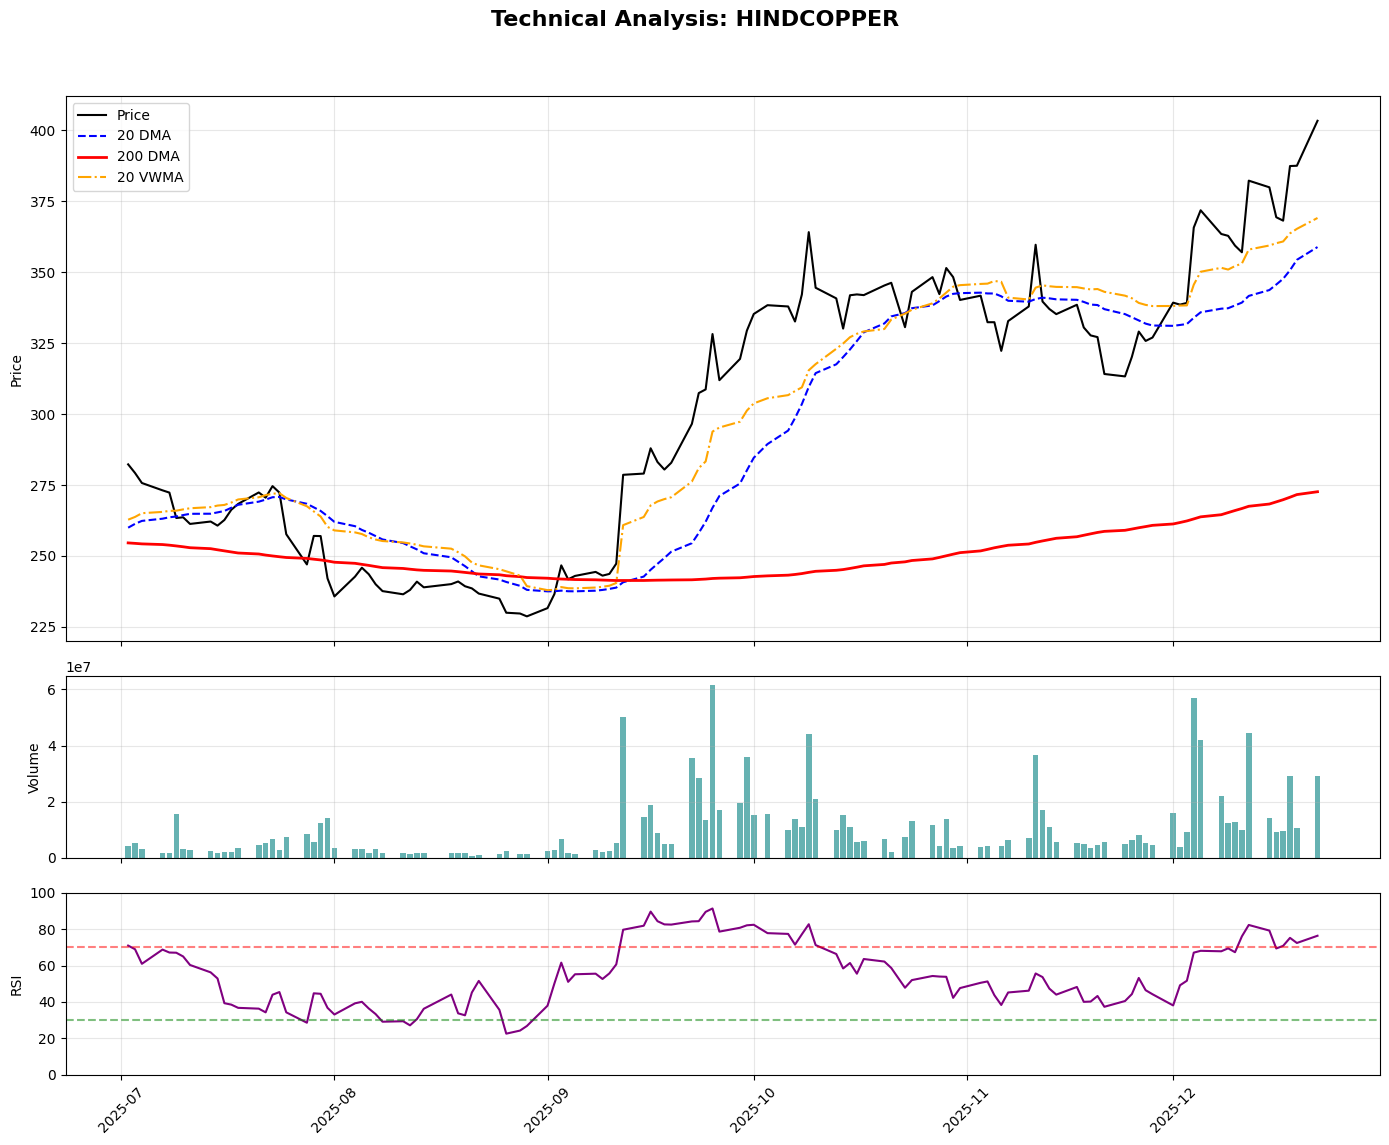

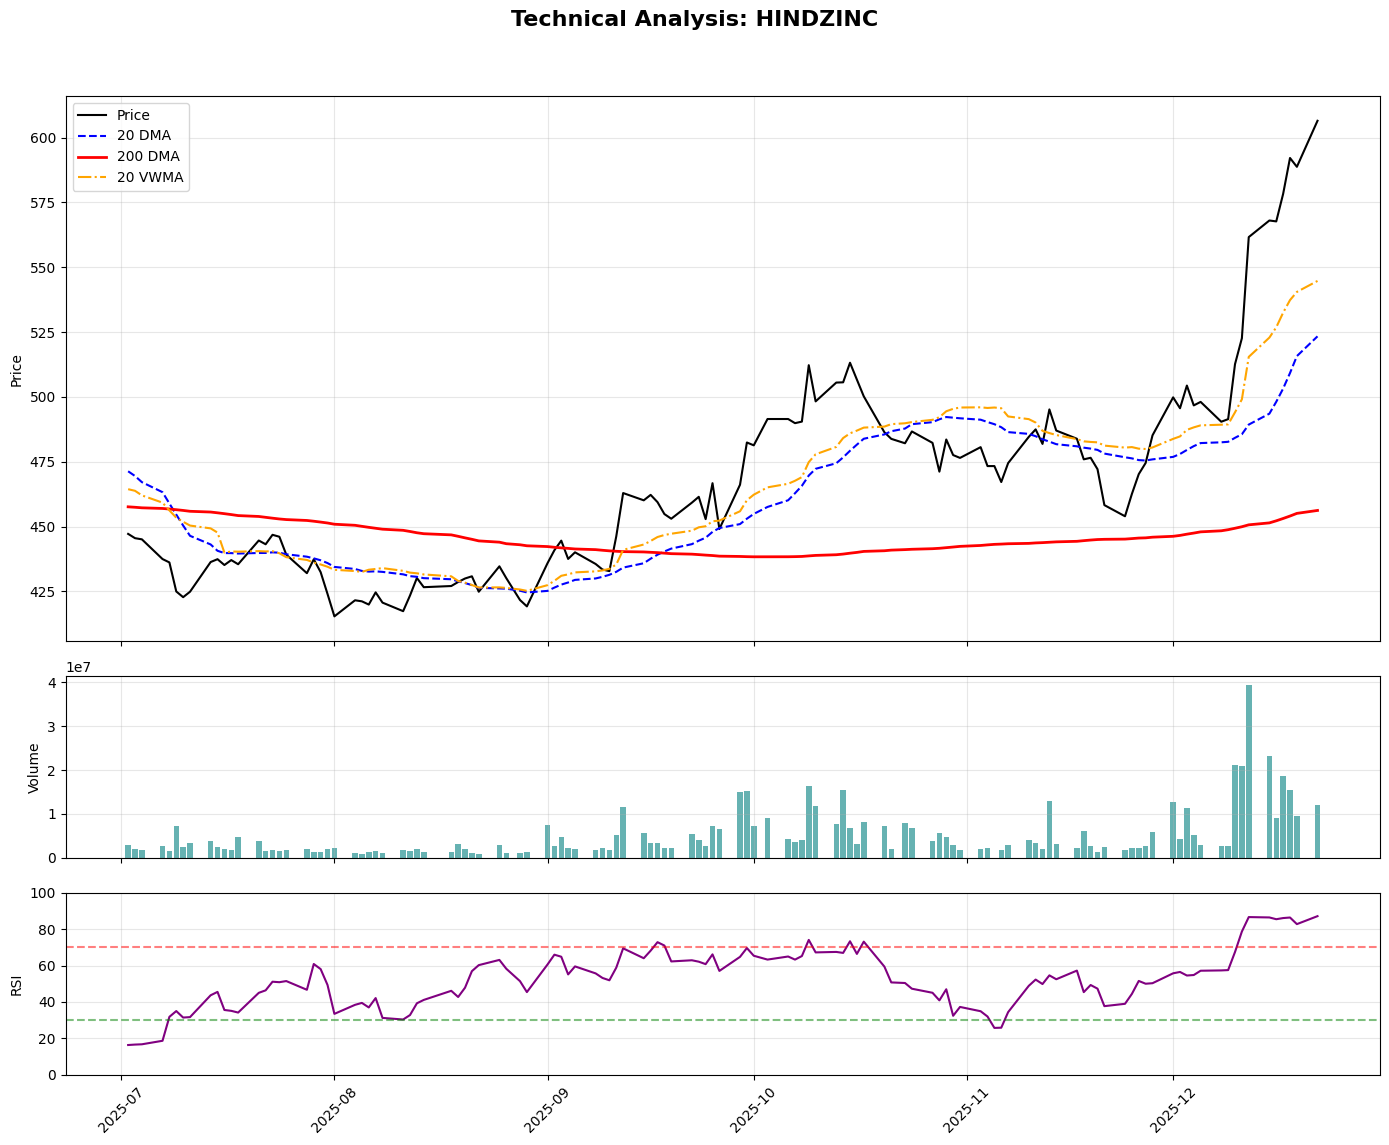

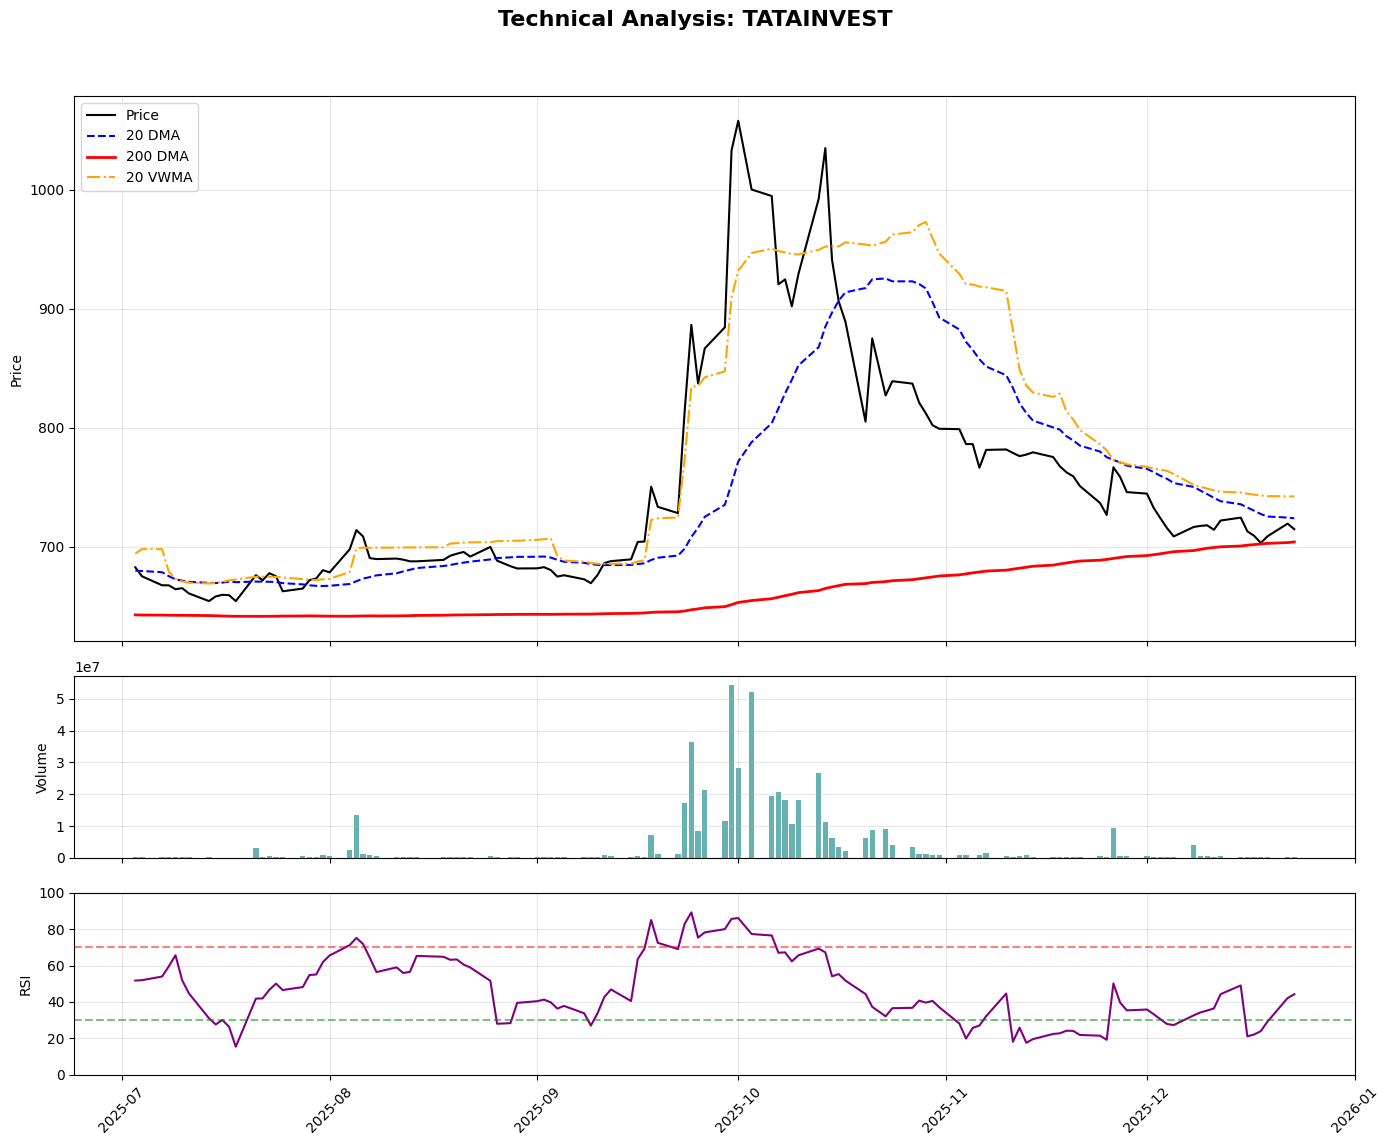

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Identify the last 3 unique dates in the dataset
last_3_dates = sorted(df['Date'].unique())[-3:]
recent_df = df[df['Date'].isin(last_3_dates)]

# Filter stocks: 20VWMA > 20dma by > 2% and 200DMA_LINE_ANGLE > 10
filtered_stocks = recent_df[
    ((recent_df['20VWMA'] - recent_df['20DMA']) / recent_df['20DMA'] > 0.02) & 
    (recent_df['200DMA_LINE_ANGLE'] > 10)
]['Ticker'].unique()

print(f"Stocks identified: {list(filtered_stocks)}")

for stock in filtered_stocks:
    # Get historical data for the stock (e.g., last 120 days for context)
    stock_df = df[df['Ticker'] == stock].sort_values('Date').tail(120)
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
    fig.suptitle(f"Technical Analysis: {stock}", fontsize=16, fontweight='bold')

    # Plot 1: Price, 20 DMA, 200 DMA, and 20 VWMA
    ax1.plot(stock_df['Date'], stock_df['Close'], label='Price', color='black', linewidth=1.5)
    ax1.plot(stock_df['Date'], stock_df['20DMA'], label='20 DMA', color='blue', linestyle='--')
    ax1.plot(stock_df['Date'], stock_df['200DMA'], label='200 DMA', color='red', linewidth=2)
    ax1.plot(stock_df['Date'], stock_df['20VWMA'], label='20 VWMA', color='orange', linestyle='-.')
    ax1.set_ylabel('Price')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Volume
    ax2.bar(stock_df['Date'], stock_df['Volume'], color='teal', alpha=0.6)
    ax2.set_ylabel('Volume')
    ax2.grid(True, alpha=0.3)

    # Plot 3: RSI
    ax3.plot(stock_df['Date'], stock_df['RSI_14'], label='RSI', color='purple')
    ax3.axhline(70, color='red', linestyle='--', alpha=0.5)
    ax3.axhline(30, color='green', linestyle='--', alpha=0.5)
    ax3.set_ylabel('RSI')
    ax3.set_ylim(0, 100)
    ax3.grid(True, alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


['AUROPHARMA']


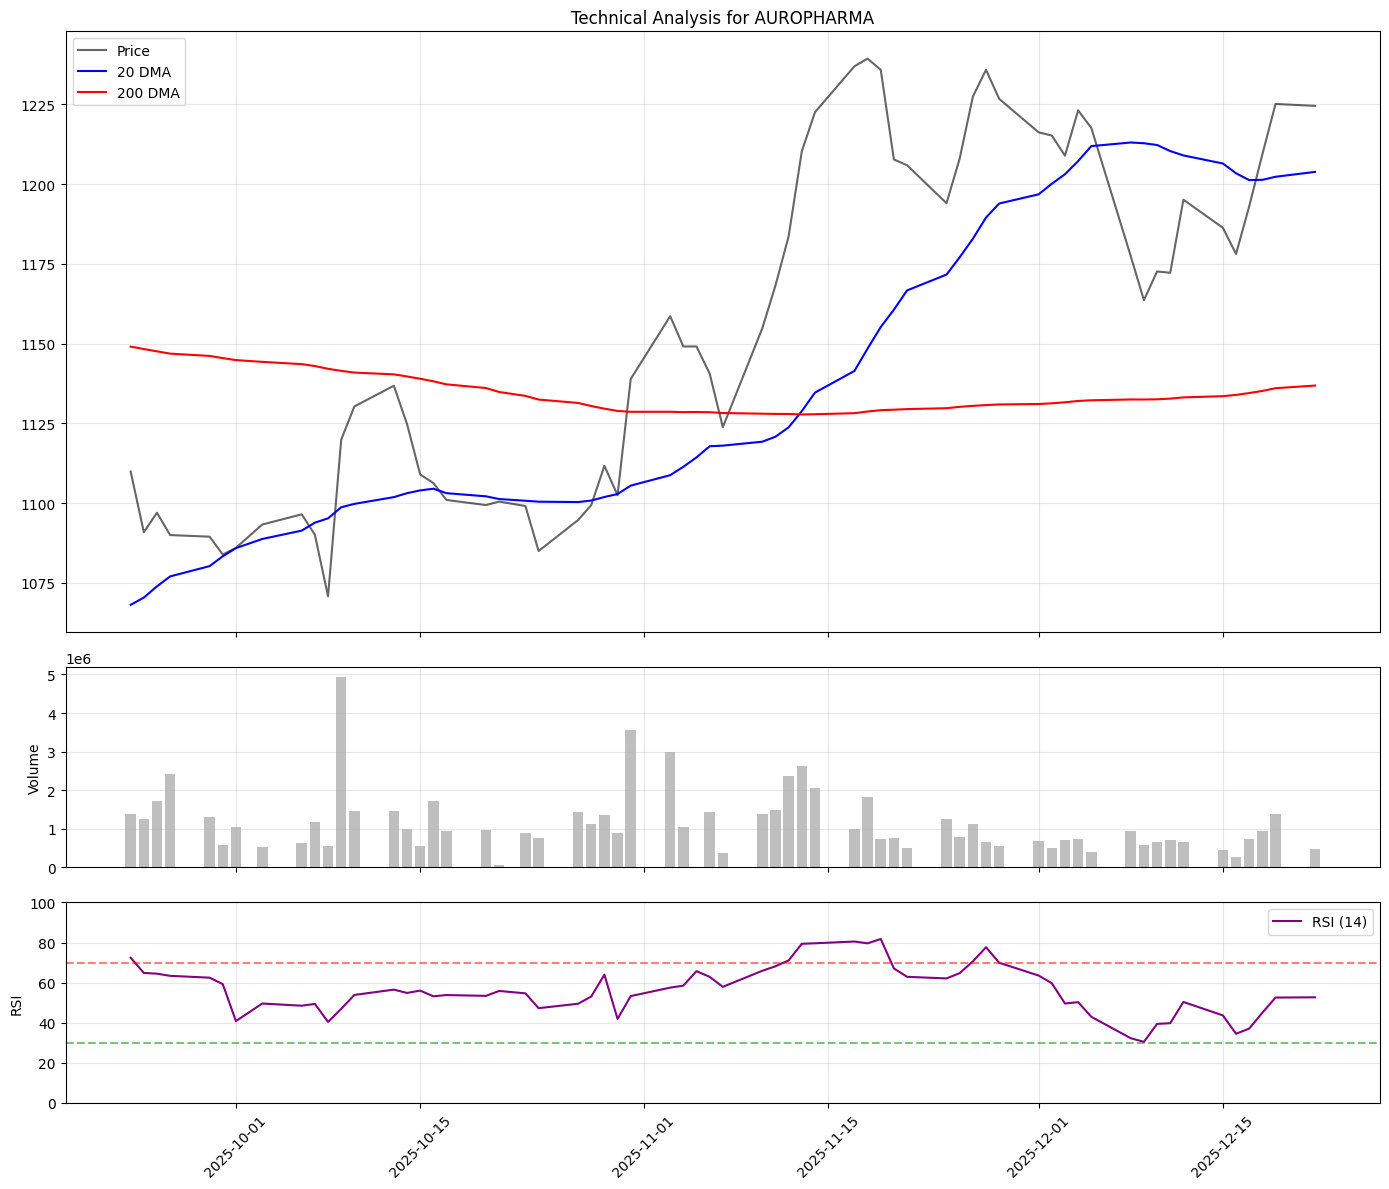

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Identify stocks meeting the criteria
def find_crossover_stocks(df):
    # Ensure data is sorted by symbol and date
    df = df.sort_values(['Ticker', 'Date'])
    
    # Calculate crossover: 20DMA was below 200DMA and is now above
    df['prev_20DMA'] = df.groupby('Ticker')['20DMA'].shift(10)
    df['prev_200DMA'] = df.groupby('Ticker')['200DMA'].shift(10)
    
    df['is_crossover'] = (df['20DMA'] > df['200DMA']) & (df['prev_20DMA'] <= df['prev_200DMA'])
    
    # Filter for criteria: crossover in last 3 days, 20DMA angle > 50, 200DMA angle > 5
    recent_df = df.groupby('Ticker').tail(20)
    matches = recent_df[
        (recent_df['is_crossover'] == True) & 
        (recent_df['20DMA_LINE_ANGLE'] -recent_df['200DMA_LINE_ANGLE']> 20) & 
        (recent_df['200DMA_LINE_ANGLE'] > 5)
    ]
    print(matches['Ticker'].unique() )
    return matches['Ticker'].unique()

identified_stocks = find_crossover_stocks(df)
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'] >= df['Date'].max() - pd.DateOffset(months=3)]

# 2. Conduct Technical Analysis and Display Charts
for stock in identified_stocks:
    stock_data = df[df['Ticker'] == stock].tail(100) # Look at last 100 days for context
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, 
                                        gridspec_kw={'height_ratios': [3, 1, 1]})
    
    # Price and Moving Averages
    ax1.plot(stock_data['Date'], stock_data['Close'], label='Price', color='black', alpha=0.6)
    ax1.plot(stock_data['Date'], stock_data['20DMA'], label='20 DMA', color='blue')
    ax1.plot(stock_data['Date'], stock_data['200DMA'], label='200 DMA', color='red')
    ax1.set_title(f"Technical Analysis for {stock}")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Volume
    ax2.bar(stock_data['Date'], stock_data['Volume'], color='gray', alpha=0.5)
    ax2.set_ylabel('Volume')
    ax2.grid(True, alpha=0.3)

    # RSI
    ax3.plot(stock_data['Date'], stock_data['RSI_14'], color='purple', label='RSI (14)')
    ax3.axhline(70, color='red', linestyle='--', alpha=0.5)
    ax3.axhline(30, color='green', linestyle='--', alpha=0.5)
    ax3.set_ylabel('RSI')
    ax3.set_ylim(0, 100)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
